# AVIP 2026 — Data Science Task 2: Titanic Dataset EDA

This notebook performs the required cleaning, feature engineering, exploratory analysis, and visualizations for the Titanic dataset.

**Required visuals:** survival rate by class/gender, age distribution histogram, and numerical correlation heatmap.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'data').exists():
    BASE_DIR = BASE_DIR.parent
DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

SOURCE_URL = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
RAW_FILE = DATA_DIR / 'titanic_raw.csv'
CLEAN_FILE = DATA_DIR / 'titanic_cleaned.csv'

print('Project:', BASE_DIR)
print('Source:', SOURCE_URL)

Project: C:\Users\User\3D Objects\internship projects\AVIP_DS_Task2_Titanic_EDA
Source: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


## 1. Load the dataset

The dataset is fetched from the documented public source so the notebook is reproducible.

In [2]:
df = pd.read_csv(SOURCE_URL)
df.to_csv(RAW_FILE, index=False)
print('Raw shape:', df.shape)
display(df.head())

Raw shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Data quality and cleaning

Cleaning steps: remove duplicates; fill numeric missing values with medians; fill categorical missing values with the mode.

In [3]:
print('Missing values before cleaning:')
display(df.isna().sum().sort_values(ascending=False))

df = df.drop_duplicates().copy()
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing values after cleaning:')
display(df.isna().sum().sort_values(ascending=False))

Missing values before cleaning:


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Missing values after cleaning:


deck           582
embark_town      2
survived         0
age              0
sibsp            0
pclass           0
sex              0
fare             0
parch            0
embarked         0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

## 3. Feature engineering

Additional analysis-ready features are created: `family_size`, `is_alone`, and simple indicator variables for sex and embarkation ports.

In [4]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['sex_male'] = (df['sex'] == 'male').astype(int)
df['embarked_c'] = (df['embarked'] == 'C').astype(int)
df['embarked_q'] = (df['embarked'] == 'Q').astype(int)
df['embarked_s'] = (df['embarked'] == 'S').astype(int)

df.to_csv(CLEAN_FILE, index=False)
print('Cleaned dataset saved to:', CLEAN_FILE)
display(df.head())

Cleaned dataset saved to: C:\Users\User\3D Objects\internship projects\AVIP_DS_Task2_Titanic_EDA\data\titanic_cleaned.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,family_size,is_alone,sex_male,embarked_c,embarked_q,embarked_s
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,2,0,1,0,0,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,2,0,0,1,0,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,1,1,0,0,0,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,2,0,0,0,0,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,1,1,1,0,0,1


## 4. Required visualization — Survival rate by class and gender

This compares observed survival rates across passenger classes and genders.

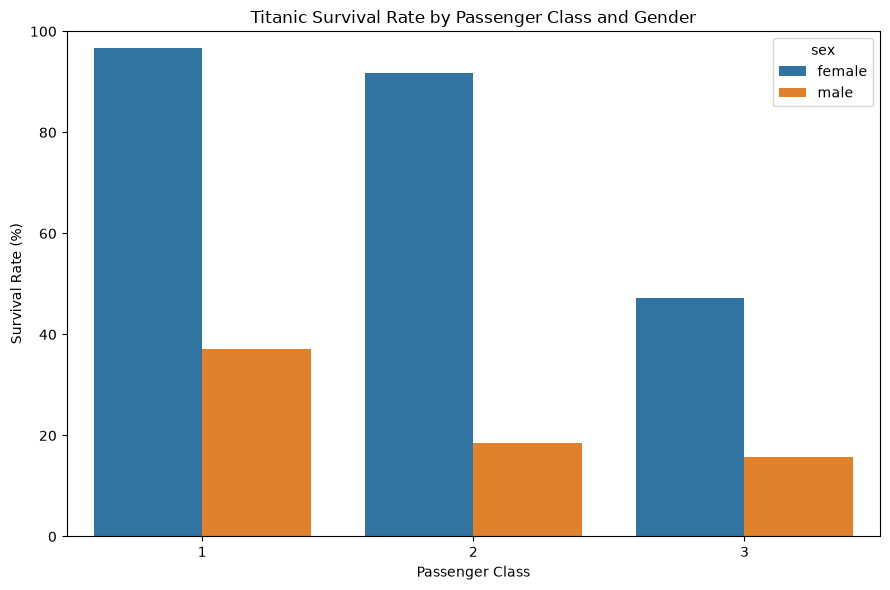

In [5]:
survival = df.groupby(['pclass', 'sex'], as_index=False)['survived'].mean()
survival['survival_rate'] = survival['survived'] * 100

plt.figure(figsize=(9, 6))
sns.barplot(data=survival, x='pclass', y='survival_rate', hue='sex')
plt.title('Titanic Survival Rate by Passenger Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'survival_rate_by_class_gender.png', dpi=180)
plt.show()

## 5. Required visualization — Age distribution

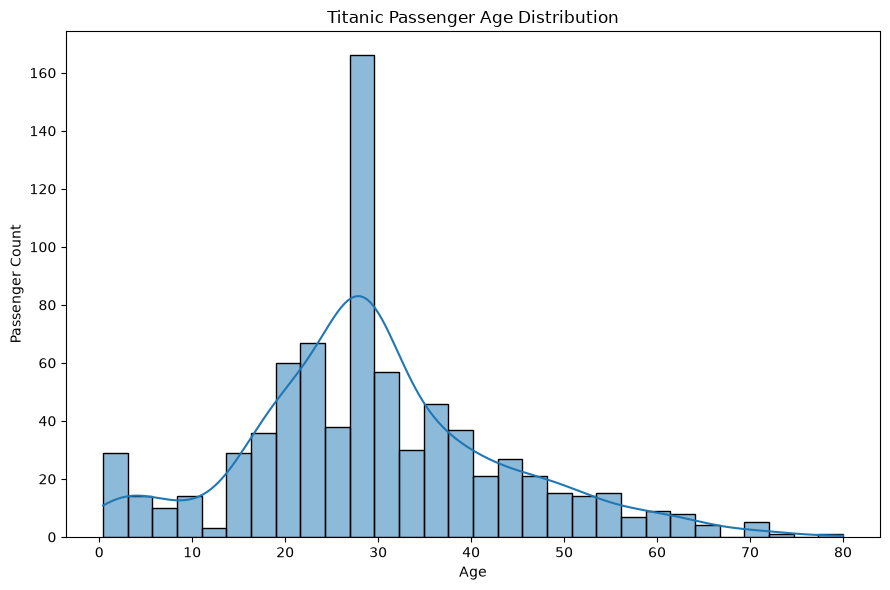

In [6]:
plt.figure(figsize=(9, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Titanic Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'age_distribution.png', dpi=180)
plt.show()

## 6. Required visualization — Correlation heatmap

The heatmap shows pairwise linear association among selected numerical features. Correlation is descriptive and does not establish causation.

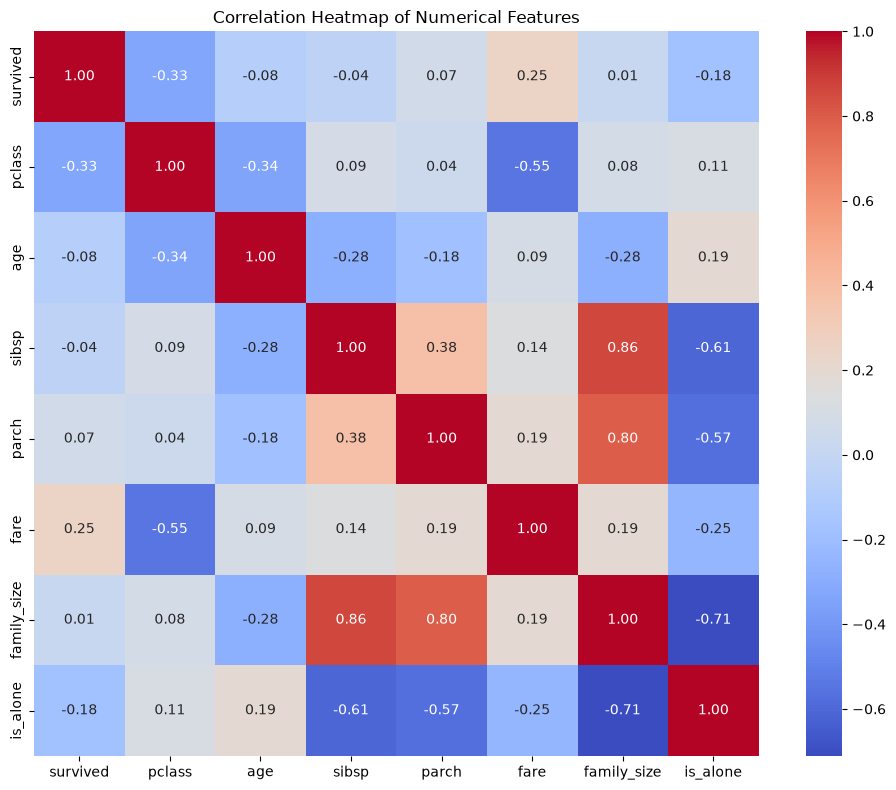

In [7]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=180)
plt.show()

## 7. Actionable observations

1. Survival varies substantially by gender, with female passengers showing a higher observed survival rate than male passengers.
2. Survival also varies by passenger class, with first-class passengers showing a higher observed survival rate than third-class passengers.
3. Age is spread across a broad range, so age can be retained as a useful continuous feature for later modelling.
4. Class and fare are associated with survival in the numerical correlation analysis; these relationships are associations rather than causal proof.

## Conclusion

The cleaned Titanic dataset supports reproducible exploratory analysis after documented missing-value handling and feature engineering. Survival differs across gender and passenger class, while age has a broad distribution. The correlation heatmap highlights relationships among numerical variables and identifies features that can be explored further in predictive modelling.